In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp

In [4]:
# Parameters

sigma = 10.0    # Prandtl number (ratio of viscosity to thermal diffusivity)
beta = 8/3      # geometric factor of the convection roll
rho = 28.0      # reduced Rayleigh number (drives convection intensity)
                # Classic chaotic regime: ρ = 28

T = 50.0        # total integration time
dt = 0.01       # timestep
t_span = (0,T)
t_eval = np.arange(0, T, dt)

In [5]:
# Lorenz vector field 
def lorenz(t, state, sigma, rho, beta):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

In [ ]:
# 1) Integrate the attractor
ic = [1.0, 1.0, 1.0]   # initial condition

sol = solve_ivp(lorenz, t_span, ic, args = (sigma, rho, beta), 
                t_eval=t_eval, method='RK45', 
                rtol=1e-10, atol=1e-12)

x, y, z = sol.y

In [ ]:
# 2) Two nearby trajectories diverging
eps=1e-4
ic2=[ic[0]+eps, ic[1], ic[2]]

sol2 = solve_ivp(lorenz, t_span, ic2, args=(sigma, rho, beta),
                t_eval=t_eval, method='RK45', 
                rtol=1e-10, atol=1e-12)

x2, y2, z2 = sol2.y

# Euclidean distance between the two trajectories over time
distance = np.sqrt((x - x2)**2 + (y - y2)**2 + (z - z2)**2)

In [8]:
# 3) Bifurcation — vary ρ

# For low ρ:  all trajectories go to a fixed point (no convection)
# At ρ ≈ 1:  pitchfork bifurcation → two stable fixed points
# At ρ ≈ 24.74: those fixed points lose stability → chaos emerges
# At ρ = 28: classic butterfly attractor
# At ρ > ~99: periodic windows appear again
#
# We integrate at four values and show the z(t) time series.

rho_values = [0.5, 5.0, 15.0, 28.0]
rho_labels = [
    "ρ = 0.5  (stable fixed point)",
    "ρ = 5    (stable fixed point)",
    "ρ = 15   (limit cycle)",
    "ρ = 28   (chaos — butterfly attractor)",
    ]

rho_colors = ['#3B82F6', '#8B5CF6', '#F59E0B', '#EF4444']

bif_solutions = []
for r in rho_values:
    s = solve_ivp(lorenz, (0,30), ic, args = (sigma, r, beta), 
                    t_eval=np.arange(0, 30, dt), method = 'RK45',
                    rtol = 1e-10, atol = 1e-12)
    bif_solutions.append(s)

Plot saved.


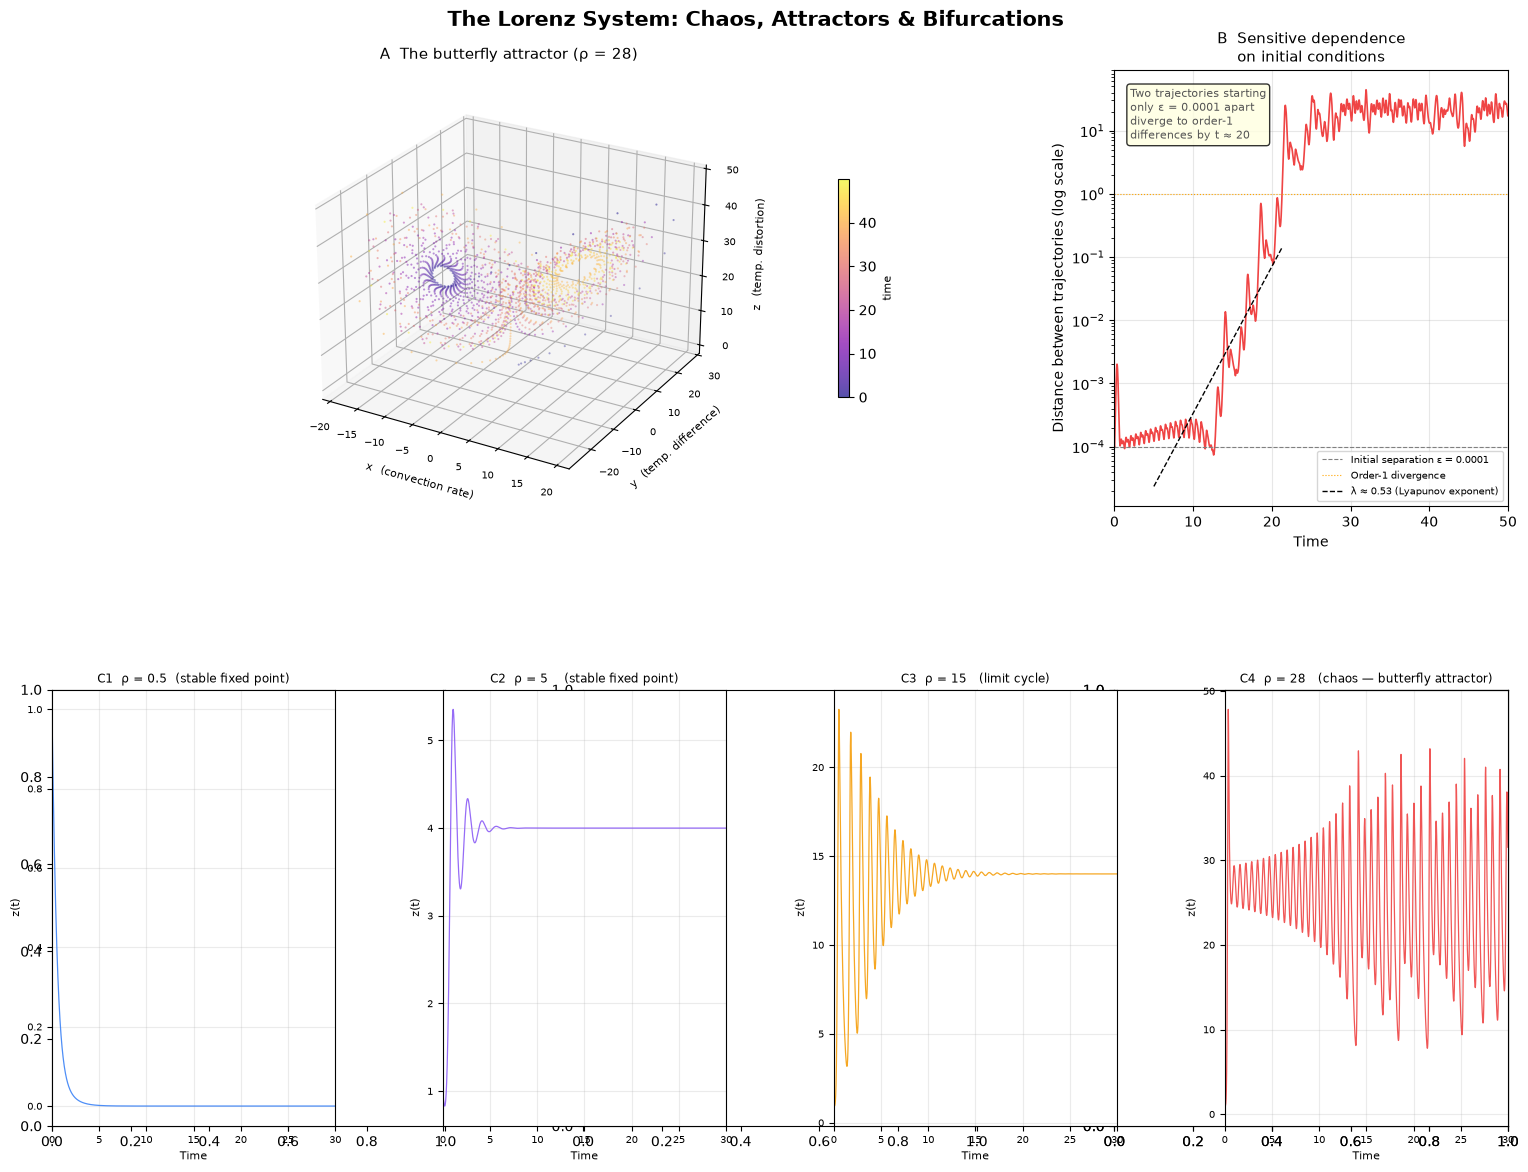

In [9]:
# Plotting
fig = plt.figure(figsize=(16, 12))
fig.suptitle("The Lorenz System: Chaos, Attractors & Bifurcations",
             fontsize=15, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35,
                       left=0.06, right=0.97, top=0.94, bottom=0.06)
 
 
# Panel A: 3D butterfly attractor 
ax1 = fig.add_subplot(gs[0, :2], projection='3d')
# Colour the trajectory by time so you can see the motion
sc = ax1.scatter(x[::3], y[::3], z[::3],
                 c=t_eval[::3], cmap='plasma', s=0.3, alpha=0.7)
ax1.set_title("A  The butterfly attractor (ρ = 28)", fontsize=11, pad=8)
ax1.set_xlabel("x  (convection rate)", fontsize=8, labelpad=4)
ax1.set_ylabel("y  (temp. difference)", fontsize=8, labelpad=4)
ax1.set_zlabel("z  (temp. distortion)", fontsize=8, labelpad=4)
ax1.tick_params(labelsize=7)
cbar = plt.colorbar(sc, ax=ax1, shrink=0.5, pad=0.12)
cbar.set_label("time", fontsize=8)
ax1.view_init(elev=25, azim=-60)
 
 
# Panel B: Sensitive dependence on initial conditions
ax2 = fig.add_subplot(gs[0, 2])
ax2.semilogy(t_eval, distance, color='#EF4444', linewidth=1.2)
ax2.axhline(y=eps, color='gray', linestyle='--', linewidth=0.8, label=f"Initial separation ε = {eps}")
ax2.axhline(y=1.0, color='orange', linestyle=':', linewidth=0.8, label="Order-1 divergence")
 
# Fit a line to the exponential growth phase to estimate the Lyapunov exponent
growth_mask = (t_eval > 5) & (distance < 1.0) & (distance > 0)
if growth_mask.sum() > 10:
    coeffs = np.polyfit(t_eval[growth_mask], np.log(distance[growth_mask]), 1)
    lyapunov_est = coeffs[0]
    t_fit = t_eval[growth_mask]
    ax2.semilogy(t_fit, np.exp(np.polyval(coeffs, t_fit)),
                 'k--', linewidth=1, label=f"λ ≈ {lyapunov_est:.2f} (Lyapunov exponent)")
 
ax2.set_title("B  Sensitive dependence\non initial conditions", fontsize=11)
ax2.set_xlabel("Time")
ax2.set_ylabel("Distance between trajectories (log scale)")
ax2.legend(fontsize=7.5, loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, T)
 
note = (f"Two trajectories starting\nonly ε = {eps} apart\n"
        f"diverge to order-1\ndifferences by t ≈ 20")
ax2.text(0.04, 0.96, note, transform=ax2.transAxes,
         fontsize=8, va='top', color='#555',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
 
 
# Panel C: z(t) time series across ρ values
for i, (sol_b, label, color) in enumerate(zip(bif_solutions, rho_labels, rho_colors)):
    ax = fig.add_subplot(gs[1, i % 3]) if i < 3 else None
    if i == 3:
        # Last panel spans remaining space — reuse third column bottom
        ax = fig.add_subplot(gs[1, 2])
 
axes_c = []
for i in range(4):
    col = i if i < 3 else 2
    ax = fig.add_subplot(gs[1, col]) if i < 3 else fig.add_subplot(gs[1, 2])
    axes_c.append(ax)
 
# Redo cleanly
for ax in axes_c:
    ax.remove()
 
gs2 = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[1, :],
                                       wspace=0.38)
for i, (sol_b, label, color) in enumerate(zip(bif_solutions, rho_labels, rho_colors)):
    ax = fig.add_subplot(gs2[i])
    t_b = sol_b.t
    z_b = sol_b.y[2]
    ax.plot(t_b, z_b, color=color, linewidth=0.9, alpha=0.9)
    ax.set_title(f"C{i+1}  {label}", fontsize=8.5, pad=5)
    ax.set_xlabel("Time", fontsize=8)
    ax.set_ylabel("z(t)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0, 30)
 
plt.savefig("/home/saral/lorenz-system/saved_plots/lorenz_system.png", dpi=150, bbox_inches='tight')
print("Plot saved.")


In [10]:
print(f"\nLorenz system parameters: σ={sigma}, β={beta:.3f}, ρ={rho}")
print(f"Initial condition: {ic}")
print(f"Nearby trajectory: {ic2}  (separation ε = {eps})")
if growth_mask.sum() > 10:
    print(f"\nEstimated largest Lyapunov exponent: λ ≈ {lyapunov_est:.3f}")
    print(f"(Known value for these parameters: λ ≈ 0.905)")
    print(f"→ Trajectories double their separation roughly every {np.log(2)/lyapunov_est:.1f} time units")



Lorenz system parameters: σ=10.0, β=2.667, ρ=28.0
Initial condition: [1.0, 1.0, 1.0]
Nearby trajectory: [1.0001, 1.0, 1.0]  (separation ε = 0.0001)

Estimated largest Lyapunov exponent: λ ≈ 0.534
(Known value for these parameters: λ ≈ 0.905)
→ Trajectories double their separation roughly every 1.3 time units
